# Librerías

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import sys
import ast
import math
import pandas as pd 
from tqdm.auto import tqdm
from pandarallel import pandarallel

pandarallel.initialize(progress_bar=True) 
tqdm.pandas()

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [53]:
sys.path.append('../src/')

In [54]:
from process_results.exists_url import apply_obtener_urls_con_progress, url_exists

# Constantes

In [55]:
PATH = '../data/results/'
PATH_OUT = '../data/analisis/'

BATCH_SIZE = 500

# Lectura de datos

In [56]:
df = pd.read_csv(PATH + 'results_gemini.csv')

# Procesamiento y exploración

In [57]:
df["references"] = df.references.apply(
    lambda x: str(x).replace('[', '').replace(']', '').split(','))

<Axes: >

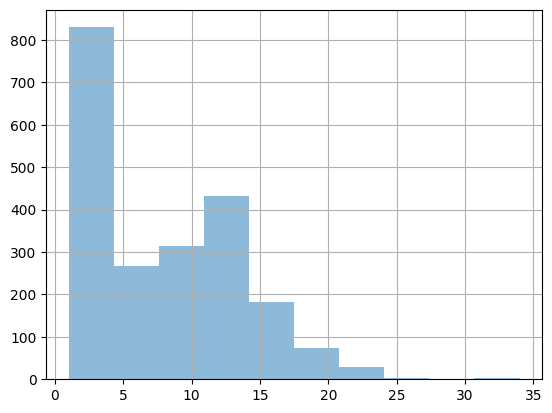

In [58]:
df['len_references'] = df['references'].apply(lambda x: len(x))
df['len_references'].hist(alpha = 0.5)

# Sacar links reales

In [ ]:
df["references_real"] = apply_obtener_urls_con_progress(df, col="references", max_workers_urls=32)

In [17]:
df.to_csv(PATH_OUT + 'results_gemini_links.csv', index = None) 

# Verificar links reales

## Lectura de datos

In [59]:
results_gemini = pd.read_csv(PATH_OUT + "results_gemini_links.csv")

## Verificar

In [60]:
results_gemini["references_real"] = results_gemini["references_real"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [24]:
output_path = PATH_OUT + "processed/gemini_url_checks_progress.csv"

try:
    already_done = pd.read_csv(output_path)
    start_idx = len(already_done)
    print(f"Retomando desde fila {start_idx}")
except FileNotFoundError:
    already_done = None
    start_idx = 0

df_to_process = results_gemini.iloc[start_idx:].copy()
total_batches = math.ceil(len(df_to_process) / BATCH_SIZE)

for batch_num, batch_start in enumerate(range(0, len(df_to_process), BATCH_SIZE)):
    batch = df_to_process.iloc[batch_start : batch_start + BATCH_SIZE].copy()

    batch["url_check"] = batch["references_real"].progress_apply(lambda x: [url_exists(i) for i in x])

    # Primera vez: escribe con header. El resto: append sin header
    is_first_write = (batch_num == 0 and already_done is None)
    batch.to_csv(output_path, mode="w" if is_first_write else "a",
                 header=is_first_write, index=False)

    print(f"--> Batch {batch_num + 1}/{total_batches} guardado ({batch_start + len(batch)} filas totales)")

print("---> Proceso completado")

  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 1/5 guardado (500 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 2/5 guardado (1000 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 3/5 guardado (1500 filas totales)


  0%|          | 0/500 [00:00<?, ?it/s]

--> Batch 4/5 guardado (2000 filas totales)


  0%|          | 0/135 [00:00<?, ?it/s]

--> Batch 5/5 guardado (2135 filas totales)
---> Proceso completado


## Procesamiento extra

In [ ]:
output_path = PATH_OUT + "processed/gemini_url_checks_progress.csv"

df = pd.read_csv(output_path)
df['url_check'] = df['url_check'].apply(lambda x: ast.literal_eval(x))

In [31]:
df['url_check']

0       [{'url': 'https://vertexaisearch.cloud.google....
1       [{'url': 'https://vertexaisearch.cloud.google....
2       [{'url': 'https://vertexaisearch.cloud.google....
3       [{'url': 'https://vertexaisearch.cloud.google....
4       [{'url': 'https://vertexaisearch.cloud.google....
                              ...                        
2130    [{'url': 'https://vertexaisearch.cloud.google....
2131    [{'url': 'https://vertexaisearch.cloud.google....
2132    [{'url': 'https://vertexaisearch.cloud.google....
2133    [{'url': 'https://vertexaisearch.cloud.google....
2134    [{'url': 'https://vertexaisearch.cloud.google....
Name: url_check, Length: 2135, dtype: object

In [30]:
# def procesar_otras_status(url_check):
#     url_check_copy = url_check.copy()
#     if url_check['status_code'] in [200, 402, 403, 406, 502, 503, 405]:
#         url_check_copy['exists'] = True
#     return url_check_copy

# df['url_check'] = df['url_check'].apply(procesar_otras_status)

df['url_check'].explode().apply(lambda x: x['exists']).value_counts()

url_check
False    16129
Name: count, dtype: int64

In [12]:
df['url_check'].apply(lambda x: x['exists']).value_counts(True)

url_check
True     0.918656
False    0.081344
Name: proportion, dtype: float64

In [19]:
df.to_csv(output_path)

## Clasificar

In [20]:
df_gemini = pd.read_csv(output_path)
print(df_gemini.shape)

(16129, 5)


In [21]:
df_gemini["url_check"] = df_gemini["url_check"].apply(
    lambda x: ast.literal_eval(x)
)

In [ ]:
from src.process_results.classify_urls import classify_url                    

In [24]:
df_gemini_revision = df_gemini[df_gemini.url_check.apply(lambda x: x['exists'])]
df_gemini_revision['clasificacion'] = df_gemini_revision['references_real'].progress_apply(
    classify_url)

  0%|          | 0/14817 [00:00<?, ?it/s]

In [25]:
print(df_gemini_revision.shape)

(14817, 6)


In [26]:
df_gemini_revision['clasificacion'].iloc[0]

{'url': 'https://papers.neurips.cc/paper_files/paper/2022/file/d3222559698f41247261b7a6c2bbaedc-Paper-Conference.pdf',
 'peer_reviewed': 'sí',
 'confianza': 'baja',
 'razon': "Heurística: patrón '/paper[s]?/' en URL",
 'doi': ''}

In [27]:
# Nuevo
df_gemini_revision['clasificacion'].apply(lambda x: x['peer_reviewed']).value_counts()

clasificacion
no    12832
sí     1985
Name: count, dtype: int64

In [28]:
df_gemini_revision['clasificacion'].apply(lambda x: x['confianza']).value_counts()

clasificacion
baja     11917
alta      2833
media       67
Name: count, dtype: int64

## 